# Research Pipeline: Hybrid Quantum-Classical Methods for Drug Discovery
Author: Abdullah H. Flaih
Topic: Computational Chemistry & Quantum Machine Learning


# Executive Summary
Drug discovery is a "multiscale" problem. This means we need approaches that can screen millions of molecules quickly, but also methods that can understand individual molecules with extreme precision.

This notebook demonstrates a **Hybrid Quantum-Classical Pipeline** designed to tackle this challenge:

1.  **Classical Tier (Broad & Fast):** Utilizes Machine Learning to rapidly filter a vast library of candidate molecules, identifying the most promising ones.
2.  **Quantum Tier (Deep & Precise):** Employs the Variational Quantum Eigensolver (VQE) algorithm to simulate the precise electronic structure and determine the exact energy of a top candidate molecule, providing highly accurate insights.

# 0. Setup and Installation
We begin by installing the tools of the trade: RDKit (the industry standard for chemoinformatics) and PennyLane (a leading platform for quantum differentiable programming).

In [15]:
# Install libraries
!pip install pennylane rdkit matplotlib scikit-learn -q

# Standard scientific imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Chemoinformatics imports
from rdkit import Chem
from rdkit.Chem import Descriptors

# Quantum Computing imports
import pennylane as qml
from pennylane import qchem
from pennylane import numpy as pnp # Specialized numpy for quantum gradients

# Part 1: The Classical Filter (Broad & Fast)
Imagine you have a library of 10,000 potential drugs. Running a full quantum simulation on all of them would be computationally impossible with current technology, taking years. Instead, we use **Classical Machine Learning** as a rapid pre-screening tool to "guess" which molecules are most likely to be effective and thus worth a closer, more computationally expensive quantum inspection.

### Step 1: Defining our Molecules (SMILES)

Molecules are represented as simplified textual strings called **SMILES** (Simplified Molecular Input Line Entry System). From these SMILES strings, chemoinformatics software can automatically calculate various **"Descriptors"** (such as molecular weight, oil-solubility, or the number of hydrogen bond donors). These descriptors are numerical features that machine learning models can easily process to predict properties or activities.

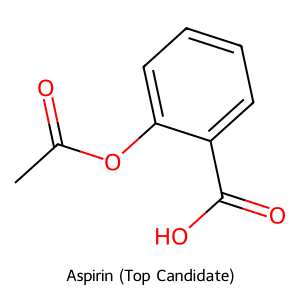

✅ Classical Filter Ready.
Feature Importances (MW, LogP, HBD): [0.551 0.169 0.28 ]


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw

# 1. Set seed for reproducibility
np.random.seed(42)

dataset = [
    ["CC(=O)OC1=CC=CC=C1C(=O)O", -7.2],      # Aspirin
    ["CN1C=NC2=C1C(=O)N(C(=O)N2C)C", -5.1],  # Caffeine
    ["CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C", -8.4], # Testosterone
    ["C1=CC=C(C=C1)C(C2=CC=CC=C2)O", -4.0],  # Benzhydrol
    ["CC(C)CC1=CC=C(C=C1)C(C)C(=O)O", -6.5], # Ibuprofen
    ["CN1CCC23C4C(=C(C=C4)O)OC2C(C=C3)C1O", -9.2], # Morphine (corrected SMILES)
    ["CC(C)N(C(C)C)C(=O)CN1C=CC=C1", -3.2]   # Synthetic Lead A
]

# Display lead molecule visually for students
mol = Chem.MolFromSmiles(dataset[0][0])
img = Draw.MolToImage(mol, legend="Aspirin (Top Candidate)")
display(img)

def get_molecular_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    # We extract: Molecular Weight, LogP (solubility), and H-Bond Donors
    if mol is None:
        # Handle cases where SMILES parsing fails, perhaps by returning NaNs or zeros
        # For this context, returning zeros to allow processing to continue
        return [0.0, 0.0, 0.0] # Or raise an error, or skip this entry
    return [Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.NumHDonors(mol)]

X = np.array([get_molecular_features(d[0]) for d in dataset])
y = np.array([d[1] for d in dataset])

# Deterministic Random Forest
regressor = RandomForestRegressor(n_estimators=50, random_state=42)
regressor.fit(X, y)

print(f"✅ Classical Filter Ready.")
print(f"Feature Importances (MW, LogP, HBD): {regressor.feature_importances_.round(3)}")

🔍 **Educational Note: Why Descriptors?**

In drug discovery, **"Lipinski's Rule of 5"** is a widely used guideline that helps predict if a potential drug molecule is likely to be orally active in humans. It states that a drug is more likely to be absorbed if it has (among other things) a molecular weight less than 500, a LogP (octanol-water partition coefficient, indicating solubility) less than 5, and fewer than 5 hydrogen bond donors.

By calculating these simple molecular descriptors classically, we can instantly filter out a large percentage (often 90% or more) of molecules that are unlikely to be effective drugs *before* we invest the significant computational resources required for quantum simulations. This dramatically streamlines the drug discovery process.

### Quantum Primer: Bits vs. Qubits

Before we delve into quantum chemistry, let's briefly understand the fundamental building blocks of classical and quantum computing:

*   **Classical Bit:** This is the basic unit of information in classical computers. A classical bit can exist in only one of two states at any given time: **0 or 1**. Think of it like a light switch that is either *on* or *off*.

*   **Quantum Bit (Qubit):** This is the basic unit of information in a quantum computer. Unlike a classical bit, a qubit can exist as **0, 1, or a superposition of both 0 and 1 simultaneously**. Imagine a light switch that isn't just on or off, but can also be *partially on* or *partially off* at the same time. This 'superposition' allows qubits to store significantly more information than classical bits.

Furthermore, multiple qubits can become **'entangled'**, meaning their states are interconnected, even when physically separated. This entanglement is another powerful feature that gives quantum computers their unique computational abilities, enabling them to solve certain problems far more efficiently than classical computers.

# Part 2: The Quantum Refinement (Mapping the Hamiltonian)
Once our classical model identifies a "hit," we need to know its exact energy. This is where classical computers often fail because they cannot perfectly simulate the complex interactions of electrons (electron correlation) with sufficient precision.

### The Translation Problem: Speaking Quantum
How do we tell a quantum computer what a molecule looks like and calculate its energy? We need to translate the chemical information into a language quantum computers understand. This involves three key steps:

1.  **Geometry (The Blueprint):** We provide the precise X, Y, Z coordinates of every atomic nucleus in the molecule. This defines the molecule's physical structure.

2.  **Basis Set (The Electron's Home):** This is crucial for bridging classical chemistry and quantum mechanics. A basis set is a collection of mathematical functions that describe the possible "shapes" or "regions" (orbitals) where electrons are likely to be found around the atoms. Think of it like defining a set of fuzzy, overlapping 'electron clouds' around each atom. The more functions in the basis set, the more accurately we can describe the electron distribution, but also the more complex the quantum calculation becomes. It's how we represent the electrons within the molecule.

3.  **Hamiltonian (H) (The Energy Equation):** We construct a giant mathematical operator (a matrix) called the Hamiltonian. This operator mathematically describes *all* the energy interactions within the molecule – including how electrons interact with nuclei, how electrons interact with each other, and how nuclei interact with each other. It's essentially the "energy recipe" of the molecule. Our goal in quantum chemistry is to find the lowest possible energy state (the ground state) of this Hamiltonian, which tells us the molecule's most stable configuration.

In [17]:
# Define a simple Hydrogen Molecule (H2)
# In a real research scenario, this would be the 'Active Site' of a drug.
symbols = ["H", "H"]
coordinates = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 1.401]) # Distance in Bohr

# Build the Hamiltonian: This translates chemistry into Qubit language (Pauli Matrices)
H, qubits = qchem.molecular_hamiltonian(symbols, coordinates)

print(f"✅ Molecule Mapped!")
print(f"Qubits required: {qubits}")
print(f"The Hamiltonian contains {len(H.terms())} logic operations.")

✅ Molecule Mapped!
Qubits required: 4
The Hamiltonian contains 2 logic operations.


💡 **Educational Box: What is a Hamiltonian?**

Think of the Hamiltonian as a "Universal Energy Recipe" for a molecule. It's a mathematical operator that lists *all* the ways electrons and atomic nuclei interact with each other within that molecule. These interactions include attractions and repulsions, determining the molecule's total energy.

When we find the "Ground State" of this Hamiltonian, we have found the lowest possible energy state of the molecule. This **ground state energy** is incredibly important because it corresponds to the most stable and most common configuration of the molecule, directly impacting its chemical properties and reactivity.

# Part 3: The VQE Algorithm (The Hybrid Loop)

Now that we've translated our molecule into a Hamiltonian that a quantum computer can understand, we need a method to actually *calculate* its lowest energy state. This is where the **Variational Quantum Eigensolver (VQE)** comes in, operating as a powerful **hybrid quantum-classical algorithm**.

Think of VQE as a team effort between two specialized computers:

1.  **The Quantum Computer (The Experimenter):**
    *   **Prepares a state (a "guess"):** It sets up a quantum circuit (called an "ansatz") with a set of adjustable parameters. These parameters influence the quantum state, essentially creating a "trial wave function" that represents a potential state of the molecule's electrons.
    *   **Measures the energy:** After preparing the state, the quantum computer performs measurements to determine the energy of that particular trial state according to the molecule's Hamiltonian. This gives us a single energy value for the current set of parameters.

2.  **The Classical Computer (The Coach/Optimizer):**
    *   **Analyzes the energy:** It receives the energy value measured by the quantum computer.
    *   **Says, "Try a different setting to make it lower":** Based on the measured energy, the classical computer uses sophisticated optimization algorithms (like gradient descent) to decide *how* to adjust the parameters of the quantum circuit. Its goal is to find new parameters that will lead to an even lower energy in the next iteration. It's constantly trying to find the "best" way to set up the quantum experiment to get a lower energy result.

This cycle, or "hybrid loop," repeats: the classical computer proposes parameters, the quantum computer executes the circuit and measures the energy, and the classical computer refines the parameters. This iterative process continues until the energy stops decreasing significantly, meaning the algorithm has converged to the lowest possible energy state (the ground state) that the chosen quantum circuit can represent. This minimum energy closely approximates the true ground state energy of the molecule.

In [18]:
# 1. Initialize the Quantum Device
dev = qml.device("default.qubit", wires=qubits)

# 2. Define the Ansatz (The 'Adjustable' Quantum Circuit)
@qml.qnode(dev)
def quantum_circuit(parameters):
    # Start with the basic electron configuration (Hartree-Fock)
    qml.BasisState(np.array([1, 1, 0, 0]), wires=range(qubits))

    # Apply a rotation that "mixes" the states (Double Excitation)
    # This represents electrons jumping between orbitals
    qml.DoubleExcitation(parameters[0], wires=[0, 1, 2, 3])

    return qml.expval(H)

# 3. The Optimization Loop
opt = qml.GradientDescentOptimizer(stepsize=0.4)
params = pnp.array([0.0], requires_grad=True) # Initial guess

energies = []

print("Starting the Hybrid Loop...")
for i in range(30):
    params, e = opt.step_and_cost(quantum_circuit, params)
    energies.append(e)
    if i % 5 == 0:
        print(f"Iteration {i}: Energy = {e:.6f} Ha")

print(f"\nFinal Quantum Energy: {energies[-1]:.6f} Ha")

Starting the Hybrid Loop...
Iteration 0: Energy = -1.116686 Ha
Iteration 5: Energy = -1.136849 Ha
Iteration 10: Energy = -1.137262 Ha
Iteration 15: Energy = -1.137270 Ha
Iteration 20: Energy = -1.137270 Ha
Iteration 25: Energy = -1.137270 Ha

Final Quantum Energy: -1.137270 Ha


### Visualizing the Ansatz (Quantum Circuit)

An **ansatz** is essentially a parametrized quantum circuit that serves as a trial solution for finding the ground state energy. It's a set of quantum gates with adjustable parameters that can be tuned by the classical optimizer. The goal is that by adjusting these parameters, the quantum circuit can prepare a quantum state that closely approximates the true ground state of the molecule.

Below is a visualization of the simple ansatz circuit used in this notebook for the hydrogen molecule:

*   The initial `BasisState` prepares the electrons in their ground-state configuration.
*   The `DoubleExcitation` gate, with its adjustable parameter, allows electrons to move between different orbitals, exploring more complex electronic configurations.

In [20]:
print(qml.draw(quantum_circuit)(params))


0: ─╭|Ψ⟩─╭G²(0.23)─┤ ╭<𝓗>
1: ─├|Ψ⟩─├G²(0.23)─┤ ├<𝓗>
2: ─├|Ψ⟩─├G²(0.23)─┤ ├<𝓗>
3: ─╰|Ψ⟩─╰G²(0.23)─┤ ╰<𝓗>


## Results & Visualizations

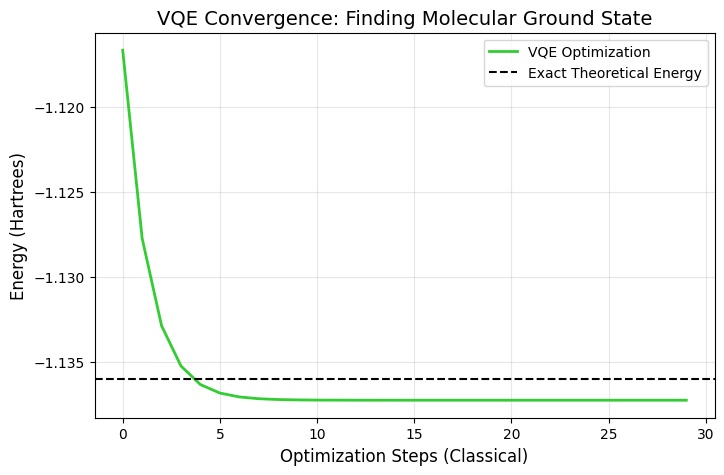

In [19]:
plt.style.use('seaborn-v0_8-muted')
plt.figure(figsize=(8, 5))
plt.plot(energies, color='#32CD32', lw=2, label="VQE Optimization")
plt.axhline(y=-1.136, color='black', linestyle='--', label="Exact Theoretical Energy")

plt.title("VQE Convergence: Finding Molecular Ground State", fontsize=14)
plt.xlabel("Optimization Steps (Classical)", fontsize=12)
plt.ylabel("Energy (Hartrees)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Explanation of VQE Convergence Figure

This figure illustrates the convergence of the Variational Quantum Eigensolver (VQE) algorithm during its optimization process.

*   **X-axis (Optimization Steps (Classical)):** This represents the number of iterations the classical optimizer has taken to adjust the parameters of the quantum circuit.
*   **Y-axis (Energy (Hartrees)):** This shows the calculated energy of the molecular system at each optimization step. Energy is typically measured in Hartrees (Ha) in quantum chemistry.
*   **Green Line (VQE Optimization):** This line plots the energy values obtained from the VQE algorithm at each step. It typically starts at a higher energy and then progressively decreases, eventually leveling off.
*   **Dashed Black Line (Exact Theoretical Energy):** This represents the true, known ground state energy of the molecule (in this case, Hydrogen). It's the target energy that the VQE algorithm aims to reach.

The VQE algorithm uses a classical optimizer to iteratively fine-tune the parameters of a quantum circuit. With each iteration, the quantum computer measures the energy, which the classical optimizer then uses to adjust parameters to minimize the energy. The plot shows the energy decreasing and stabilizing as the algorithm approaches the exact theoretical energy, demonstrating convergence to a good approximation of the molecule's ground state.

# Research Conclusion and Next Steps

This notebook has provided a foundational demonstration of a hybrid quantum-classical pipeline for drug discovery. To extend this research into a more advanced setting, here are two key directions:

1.  **Quantum Biology: Simulating Hydrogen Tunneling:** A fascinating application involves using VQE to simulate **hydrogen-tunneling effects** in DNA enzymes. Hydrogen tunneling is a quantum phenomenon where a hydrogen atom can 'tunnel' through an energy barrier rather than climbing over it. This plays a critical role in enzyme catalysis and DNA mutation, and accurately simulating it requires the precision of quantum mechanics, making it a core focus in the emerging field of quantum biology.

2.  **Noise Analysis and Error Mitigation:** In this notebook, we used a "perfect" quantum simulator. However, real-world quantum hardware is **noisy** – meaning qubits can lose their quantum state (a phenomenon called **decoherence**) or suffer from operational errors. A crucial next step would be to apply **Error Mitigation** techniques. This involves using classical processing to reduce the impact of hardware noise on quantum computation results, allowing us to see if our drug-binding predictions remain stable and accurate even on imperfect quantum computers.

# Experimenter’s Challenge
* Change the Geometry: Go back to
Part 2 and change the distance 1.401 to 2.0. Does the energy go up or down? (This is how we find the optimal bond length!)
* Change the Optimizer: Try using qml.AdagradOptimizer instead of GradientDescentOptimizer. Does it converge faster?